In [1]:
pip install missingno


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install covid19dh


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from covid19dh import covid19
import missingno as msno

In [4]:
from datetime import date
x, src = covid19("USA", level=2, start = date(2020,12,1), end = "2021-03-01")

We have invested a lot of time and effort in creating COVID-19 Data Hub, please cite the following when using it:

	Guidotti, E., Ardia, D., (2020), "COVID-19 Data Hub", Journal of Open Source Software 5(51):2376, doi: 10.21105/joss.02376.

A BibTeX entry for LaTeX users is

	@Article{,
		title = {COVID-19 Data Hub},
		year = {2020},
		doi = {10.21105/joss.02376},
		author = {Emanuele Guidotti and David Ardia},
		journal = {Journal of Open Source Software},
		volume = {5},
		number = {51},
		pages = {2376},
	}

To hide this message use 'verbose = False'.


In [5]:
x.head()

,id,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,...,iso_alpha_3,iso_alpha_2,iso_numeric,iso_currency,key_local,key_google_mobility,key_apple_mobility,key_jhu_csse,key_nuts,key_gadm
40617,10b692cc,2020-12-01,106.0,2.0,29.0,24553.0,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40618,10b692cc,2020-12-02,106.0,2.0,29.0,24565.0,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40619,10b692cc,2020-12-03,106.0,2.0,29.0,24737.0,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40620,10b692cc,2020-12-04,106.0,2.0,29.0,24763.0,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP
40621,10b692cc,2020-12-05,106.0,2.0,29.0,24932.0,NaN,NaN,NaN,NaN,...,USA,US,840.0,USD,69,NaN,Northern Mariana Islands,US69,NaN,MNP


In [6]:
x.shape


(5096, 47)

In [7]:
state_party_affiliation_2020_2021=pd.read_csv("state_party_affiliation_2020_2021.csv")

In [8]:
joint=x.merge(state_party_affiliation_2020_2021,left_on="administrative_area_level_2", right_on="State")


In [9]:
joint.head()

,id,date,confirmed,deaths,recovered,tests,vaccines,people_vaccinated,people_fully_vaccinated,hosp,...,iso_numeric,iso_currency,key_local,key_google_mobility,key_apple_mobility,key_jhu_csse,key_nuts,key_gadm,State,Party
0,121cd66e,2020-12-01,322371.0,3674.0,279540.0,5352284.0,NaN,NaN,NaN,1999.0,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
1,121cd66e,2020-12-02,327536.0,3751.0,286219.0,5411175.0,NaN,NaN,NaN,1974.0,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
2,121cd66e,2020-12-03,333685.0,3843.0,290019.0,5485069.0,NaN,NaN,NaN,1849.0,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
3,121cd66e,2020-12-04,339032.0,3904.0,293151.0,5566255.0,NaN,NaN,NaN,1802.0,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic
4,121cd66e,2020-12-05,345340.0,3979.0,301081.0,5630639.0,NaN,NaN,NaN,1790.0,...,840.0,USD,27,ChIJmwt4YJpbWE0RD6L-EJvJogI,Minnesota,US27,NaN,USA.24_1,Minnesota,Democratic


In [10]:
joint['State'].unique()

array(['Minnesota', 'California', 'Florida', 'Wyoming', 'South Dakota',
       'Kansas', 'Nevada', 'Virginia', 'Washington', 'Oregon',
       'Wisconsin', 'New Jersey', 'Rhode Island', 'Vermont',
       'North Carolina', 'Oklahoma', 'Alabama', 'Delaware', 'Missouri',
       'Utah', 'Mississippi', 'Connecticut', 'Indiana', 'Georgia',
       'Texas', 'Pennsylvania', 'Massachusetts', 'Maine', 'Tennessee',
       'Michigan', 'Idaho', 'Illinois', 'Louisiana', 'New Mexico',
       'Arizona', 'Arkansas', 'Nebraska', 'West Virginia',
       'South Carolina', 'New York', 'Kentucky', 'Ohio', 'Alaska',
       'New Hampshire', 'North Dakota', 'Iowa', 'Montana', 'Hawaii',
       'Maryland', 'Colorado'], dtype=object)

In [11]:
analysis_dta = joint[[
    'State',
    'Party',
    'school_closing',
    'workplace_closing',
    'cancel_events',
    'gatherings_restrictions',
    'transport_closing',
    'stay_home_restrictions',
    'internal_movement_restrictions',
    'international_movement_restrictions',
    'information_campaigns',
    'testing_policy',
    'contact_tracing',
    'facial_coverings',
    'vaccination_policy'
]]


In [12]:
analysis_dta.head()

,State,Party,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy
0,Minnesota,Democratic,-2.0,2.0,2.0,4.0,1.0,1.0,1.0,3.0,2.0,3.0,1.0,2.0,0.0
1,Minnesota,Democratic,-2.0,2.0,2.0,4.0,1.0,1.0,1.0,3.0,2.0,3.0,1.0,2.0,0.0
2,Minnesota,Democratic,-2.0,2.0,2.0,4.0,1.0,1.0,1.0,3.0,2.0,3.0,1.0,2.0,0.0
3,Minnesota,Democratic,-2.0,2.0,2.0,4.0,1.0,1.0,1.0,3.0,2.0,3.0,1.0,2.0,0.0
4,Minnesota,Democratic,-2.0,2.0,2.0,4.0,1.0,1.0,1.0,3.0,2.0,3.0,1.0,2.0,0.0


In [13]:
analysis_dta.shape

(4550, 15)

In [14]:
policy_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'international_movement_restrictions',
    'information_campaigns', 'testing_policy', 'contact_tracing',
    'facial_coverings', 'vaccination_policy'
]

analysis_dta[policy_cols] = analysis_dta[policy_cols].abs()

# Group by State and Party (both collapse since Party is constant within state)
analysis_dta = analysis_dta.groupby(['State', 'Party'], as_index=False)[policy_cols].mean()

/tmp/ipykernel_16226/3714010353.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_dta[policy_cols] = analysis_dta[policy_cols].abs()


In [15]:
analysis_dta.head()

,State,Party,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy
0,Alabama,Republican,2.000000,1.000000,1.000000,0.000000,0.0,1.000000,1.00000,3.0,2.0,2.681319,1.00000,3.0,1.615385
1,Alaska,Republican,2.538462,1.340659,2.000000,4.000000,0.0,1.000000,2.00000,3.0,2.0,3.000000,1.00000,3.0,1.868132
2,Arizona,Republican,2.000000,1.615385,1.934066,3.000000,0.0,1.000000,1.00000,3.0,2.0,3.000000,2.00000,3.0,1.582418
3,Arkansas,Republican,1.978022,1.670330,1.000000,2.769231,1.0,1.000000,1.00000,3.0,2.0,2.615385,2.00000,3.0,2.032967
4,California,Democratic,3.000000,2.000000,2.000000,4.000000,0.0,1.626374,1.67033,3.0,2.0,3.000000,1.43956,3.0,1.692308


In [16]:
analysis_dta.shape

(50, 15)

In [17]:
pip install geopandas

Note: you may need to restart the kernel to use updated packages.


Index(['id', 'name', 'density', 'geometry'], dtype='object')


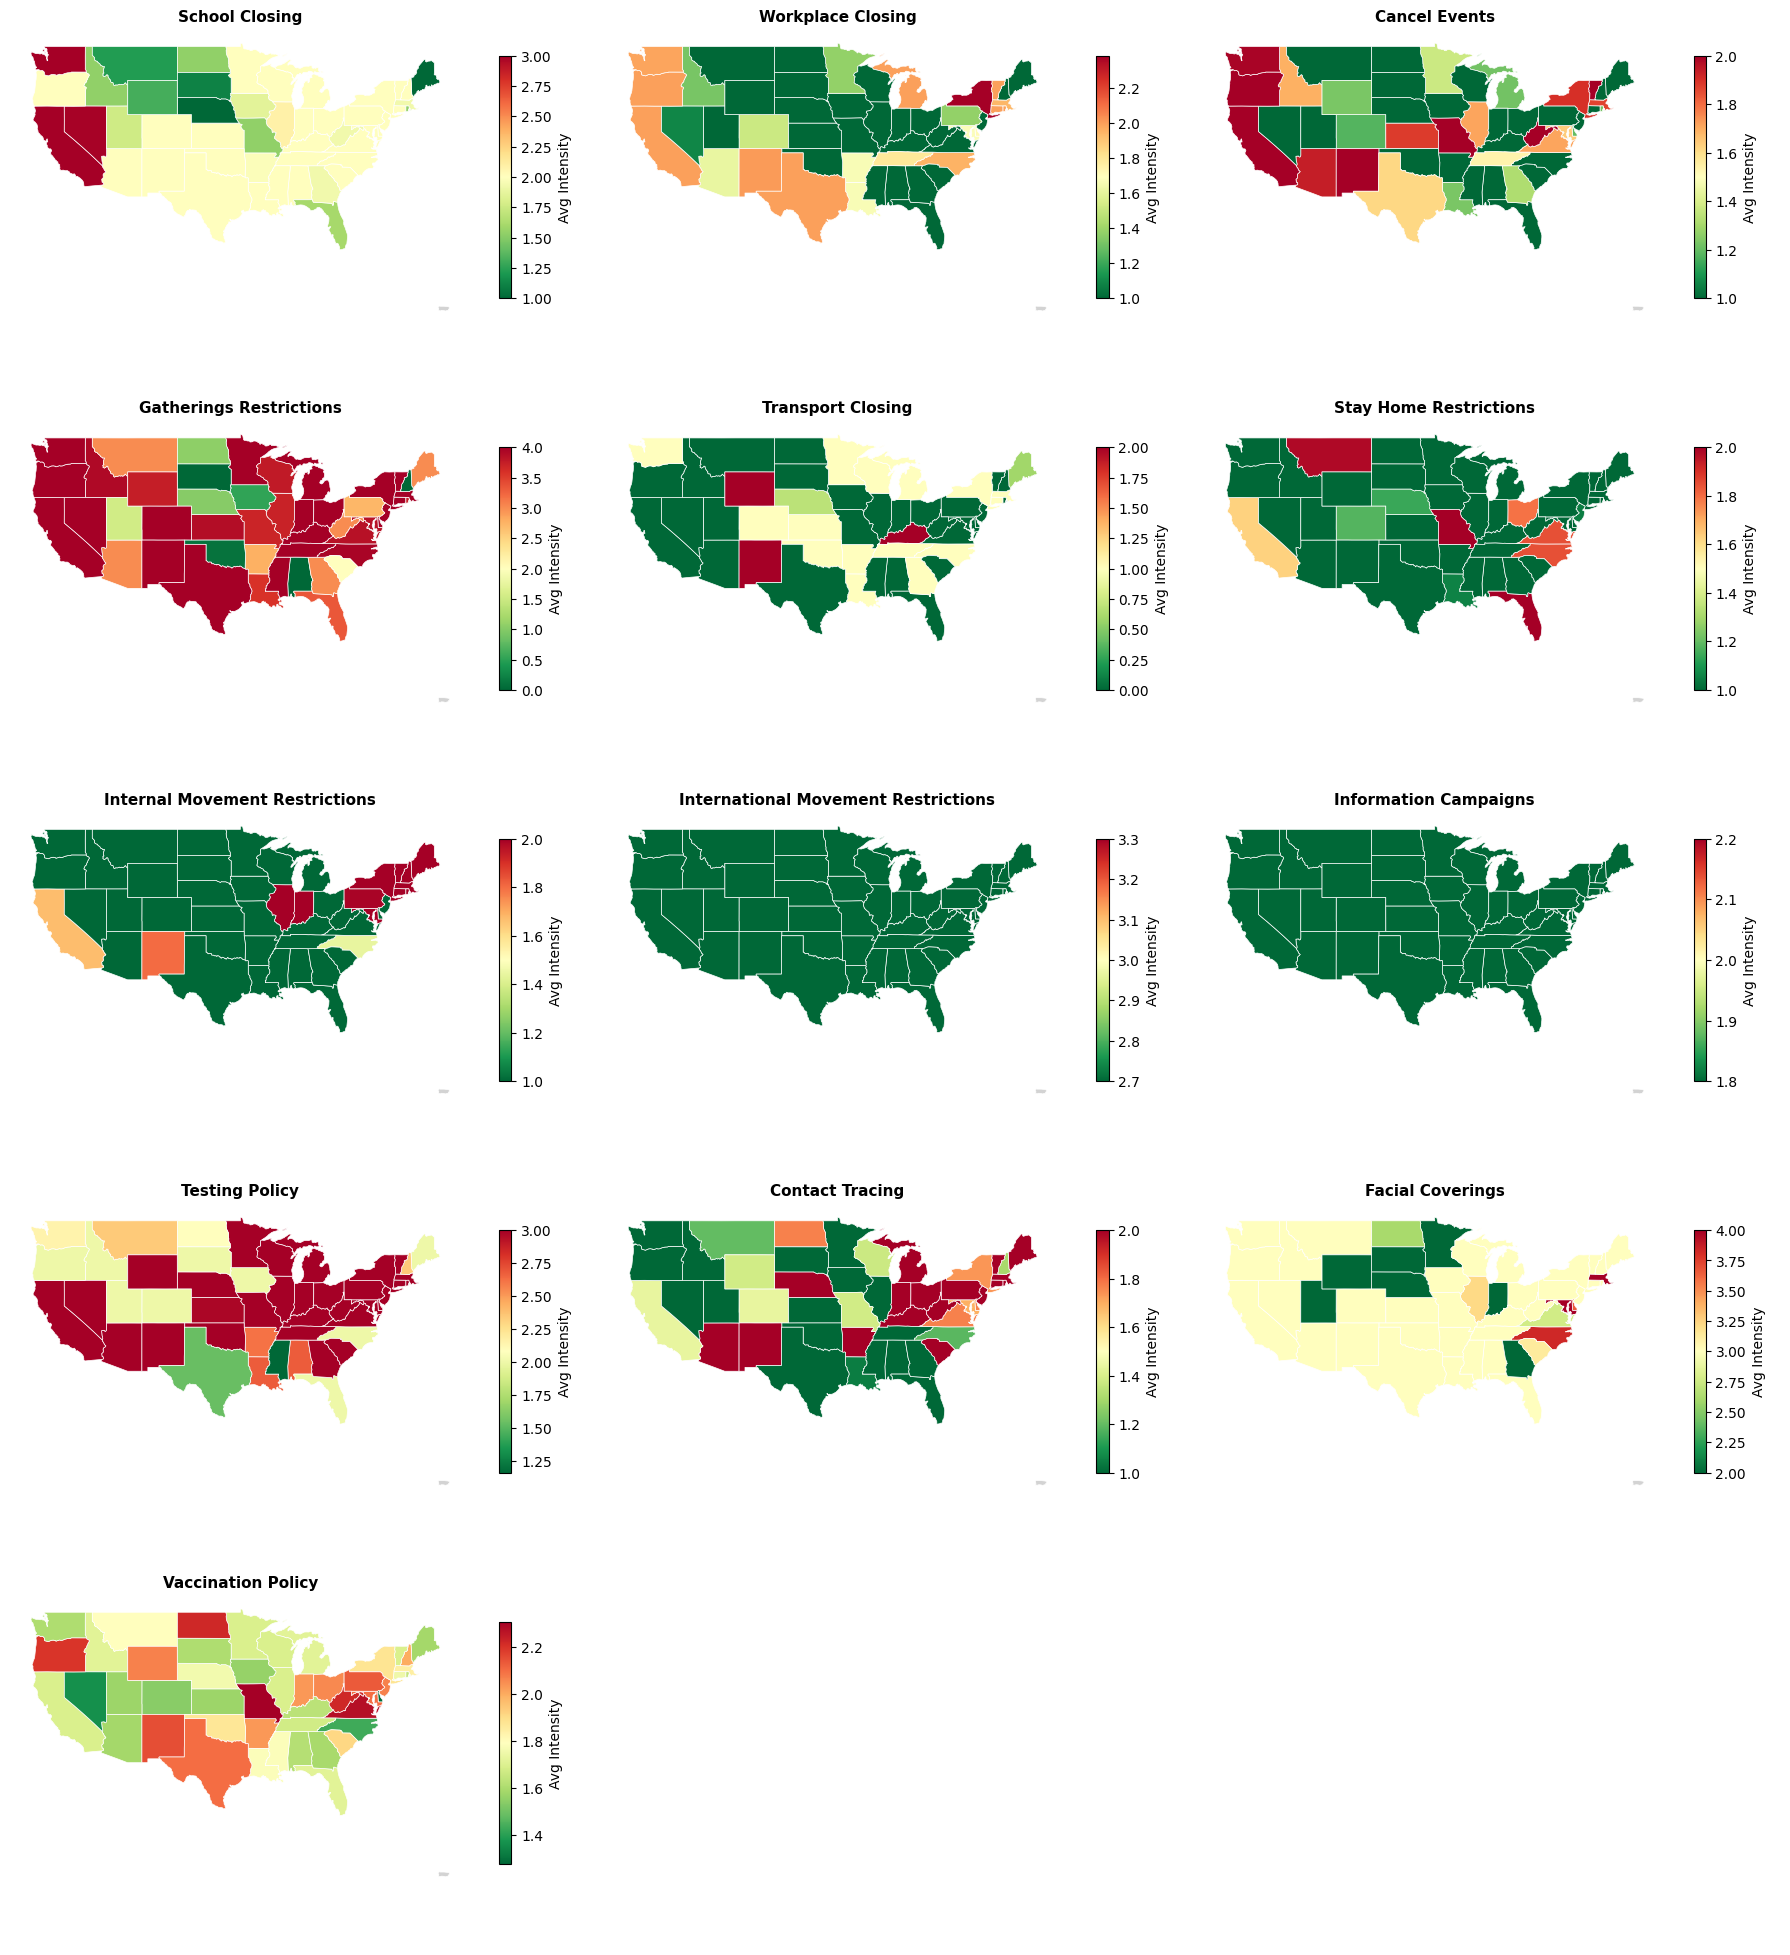

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load US states shapefile — geopandas has this built in
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
gdf = gpd.read_file(url)

# Merge with your data — check what the state name column is called in gdf
print(gdf.columns)  # likely 'name'
gdf = gdf.merge(analysis_dta, left_on='name', right_on='State', how='left')

# Drop Alaska and Hawaii for cleaner continental US map (optional)
gdf = gdf[~gdf['name'].isin(['Alaska', 'Hawaii'])]

# Plot one map per policy variable in a grid
n_cols = 3
n_rows = -(-len(policy_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(policy_cols):
    ax = axes[i]
    gdf.plot(
        column=col,
        ax=ax,
        cmap='RdYlGn_r',     # red = high restriction, green = low
        legend=True,
        legend_kwds={
            'shrink': 0.6,
            'label': 'Avg Intensity'
        },
        missing_kwds={'color': 'lightgrey', 'label': 'No data'},
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [19]:
feature_cols=['State',
    'school_closing',
    'workplace_closing',
    'cancel_events',
    'gatherings_restrictions',
    'transport_closing',
    'stay_home_restrictions',
    'internal_movement_restrictions',
    'testing_policy',
    'contact_tracing',
    'facial_coverings']


In [39]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, RocCurveDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# =============================================================================
# STEP 1: PREP
# =============================================================================

feature_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'testing_policy', 'contact_tracing',
    'facial_coverings'
]
# Note: dropping 'State' from features — it's an identifier not a predictor

X = analysis_dta[feature_cols]
y = analysis_dta['Party']  # 'Republican' / 'Democratic'

# =============================================================================
# STEP 2: TRAIN/TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # ensures both splits have balanced R/D representation
)

print(f"Training set: {len(X_train)} states")
print(f"Test set:     {len(X_test)} states")
print(f"\nTraining Party distribution:\n{y_train.value_counts()}")
print(f"\nTest Party distribution:\n{y_test.value_counts()}")

# =============================================================================
# STEP 3: SCALE AND FIT
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
# C=0.1 = regularization, important with small N
model.fit(X_train_scaled, y_train)


Training set: 35 states
Test set:     15 states

Training Party distribution:
Party
Republican    18
Democratic    17
Name: count, dtype: int64

Test Party distribution:
Party
Republican    8
Democratic    7
Name: count, dtype: int64


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [40]:
# =============================================================================
# STEP 4: EVALUATE
# =============================================================================

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_prob):.3f}")



--- Classification Report ---
              precision    recall  f1-score   support

  Democratic       0.40      0.29      0.33         7
  Republican       0.50      0.62      0.56         8

    accuracy                           0.47        15
   macro avg       0.45      0.46      0.44        15
weighted avg       0.45      0.47      0.45        15

AUC: 0.589


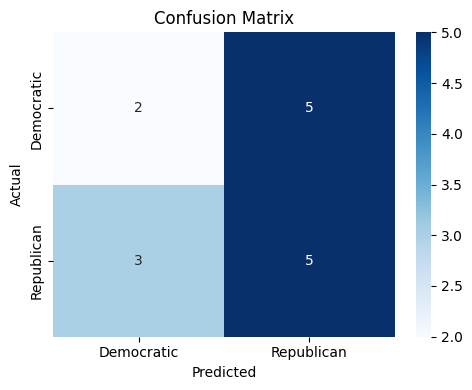

In [41]:
# =============================================================================
# STEP 5: CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

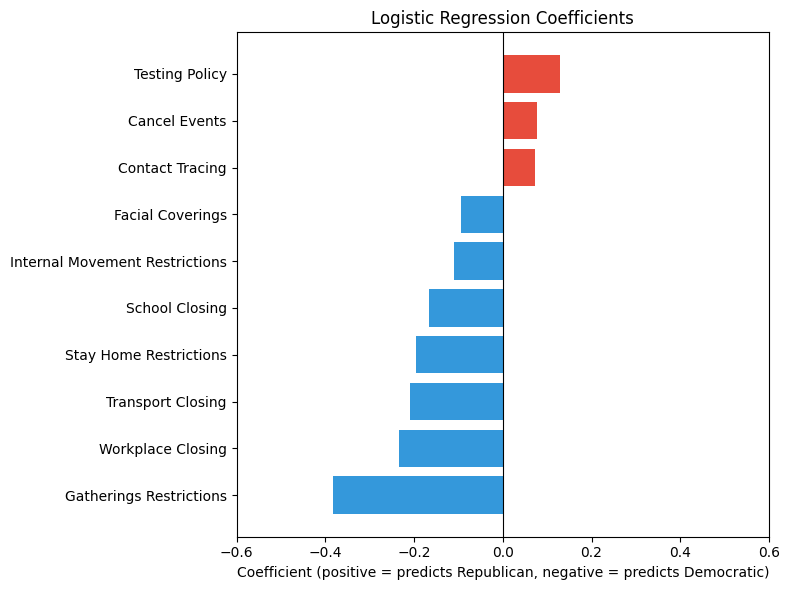


Coefficients (sorted by abs value):
                          feature  coefficient
3         gatherings_restrictions    -0.381980
1               workplace_closing    -0.233085
4               transport_closing    -0.208971
5          stay_home_restrictions    -0.194605
0                  school_closing    -0.167450
7                  testing_policy     0.128789
6  internal_movement_restrictions    -0.109560
9                facial_coverings    -0.093907
2                   cancel_events     0.077073
8                 contact_tracing     0.073603


In [42]:
# =============================================================================
# STEP 6: COEFFICIENTS — which policies matter most
# =============================================================================

coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'].str.replace('_', ' ').str.title(),
        coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-0.6, 0.6)
ax.set_xlabel(f'Coefficient (positive = predicts {model.classes_[1]}, negative = predicts {model.classes_[0]})')
ax.set_title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

print("\nCoefficients (sorted by abs value):")
print(coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index))


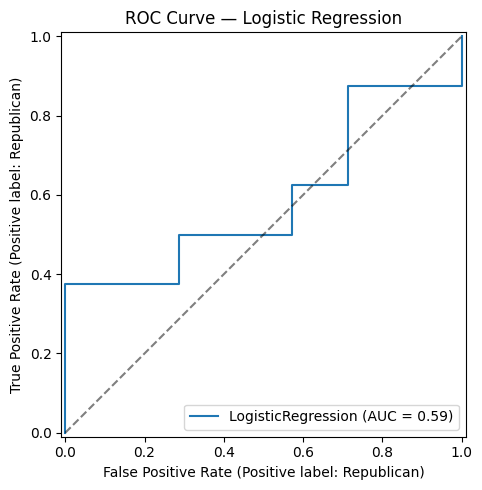

In [43]:

# =============================================================================
# STEP 7: ROC CURVE
# =============================================================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

In [44]:


# =============================================================================
# STEP 8: SEE WHICH STATES WERE MISCLASSIFIED
# =============================================================================

test_states = analysis_dta.loc[X_test.index, 'State'].values

results_df = pd.DataFrame({
    'State':          test_states,
    'Actual':         y_test.values,
    'Predicted':      y_pred,
    'Prob_class1':    y_pred_prob.round(3),
    'Correct':        y_test.values == y_pred
}).sort_values('Prob_class1', ascending=False)

print("\nTest set predictions:")
print(results_df.to_string(index=False))
print(f"\nMisclassified states:")
print(results_df[~results_df['Correct']][['State', 'Actual', 'Predicted', 'Prob_class1']])


Test set predictions:
        State     Actual  Predicted  Prob_class1  Correct
 South Dakota Republican Republican        0.866     True
 North Dakota Republican Republican        0.800     True
New Hampshire Republican Republican        0.772     True
   New Jersey Democratic Republican        0.614    False
 Pennsylvania Democratic Republican        0.613    False
      Wyoming Republican Republican        0.552     True
       Kansas Democratic Republican        0.531    False
    Wisconsin Democratic Republican        0.517    False
         Ohio Republican Republican        0.515     True
 Rhode Island Democratic Republican        0.507    False
     Maryland Republican Democratic        0.447    False
  Mississippi Republican Democratic        0.442    False
     Kentucky Democratic Democratic        0.429     True
     Michigan Democratic Democratic        0.406     True
        Texas Republican Democratic        0.370    False

Misclassified states:
           State      Actu

In [26]:
state_party_affiliation_2020_2021=pd.read_csv("pol_lean.csv")
leaning=analysis_dta.merge(state_party_affiliation_2020_2021, how='left', on="State")


In [27]:
leaning.head()

,State,Party,school_closing,workplace_closing,cancel_events,gatherings_restrictions,transport_closing,stay_home_restrictions,internal_movement_restrictions,international_movement_restrictions,information_campaigns,testing_policy,contact_tracing,facial_coverings,vaccination_policy,Unnamed: 0,Partisan Lean,Party of Partisan Lean
0,Alabama,Republican,2.000000,1.000000,1.000000,0.000000,0.0,1.000000,1.00000,3.0,2.0,2.681319,1.00000,3.0,1.615385,43,-29.6,Republican
1,Alaska,Republican,2.538462,1.340659,2.000000,4.000000,0.0,1.000000,2.00000,3.0,2.0,3.000000,1.00000,3.0,1.868132,31,-14.6,Republican
2,Arizona,Republican,2.000000,1.615385,1.934066,3.000000,0.0,1.000000,1.00000,3.0,2.0,3.000000,2.00000,3.0,1.582418,26,-7.6,Republican
3,Arkansas,Republican,1.978022,1.670330,1.000000,2.769231,1.0,1.000000,1.00000,3.0,2.0,2.615385,2.00000,3.0,2.032967,44,-31.8,Republican
4,California,Democratic,3.000000,2.000000,2.000000,4.000000,0.0,1.626374,1.67033,3.0,2.0,3.000000,1.43956,3.0,1.692308,5,25.5,Democrat


In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
# =============================================================================
# STEP 1: PREP
# =============================================================================

feature_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'testing_policy', 'contact_tracing',
    'facial_coverings'
]
# Note: dropping 'State' from features — it's an identifier not a predictor

X = leaning[feature_cols]
y = leaning['Partisan Lean']  # 'Republican' / 'Democratic'

# =============================================================================
# STEP 2: TRAIN/TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42   # ensures both splits have balanced R/D representation
)

print(f"Training set: {len(X_train)} states")
print(f"Test set:     {len(X_test)} states")
print(f"\nTraining Party distribution:\n{y_train.value_counts()}")
print(f"\nTest Party distribution:\n{y_test.value_counts()}")

# =============================================================================
# STEP 3: SCALE AND FIT
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

model = LinearRegression()
model.fit(X_train_scaled, y_train)


Training set: 40 states
Test set:     10 states

Training Party distribution:
Partisan Lean
-7.6     2
-37.2    2
 25.5    1
-2.9     1
-31.8    1
 13.4    1
 12.1    1
-29.4    1
-35.5    1
 12.4    1
-7.4     1
-27.1    1
-21.2    1
-20.7    1
-12.4    1
 20.0    1
 27.5    1
-29.6    1
-2.5     1
 6.4     1
 12.0    1
-37.0    1
 10.6    1
-14.6    1
-1.6     1
-26.3    1
-20.3    1
-32.2    1
 31.6    1
 1.9     1
 4.0     1
-49.7    1
 32.6    1
 13.7    1
-12.0    1
-9.7     1
 0.3     1
 24.0    1
Name: count, dtype: int64

Test Party distribution:
Partisan Lean
-20.0    2
-18.6    1
 7.0     1
 4.6     1
-20.5    1
-4.1     1
-24.8    1
-4.8     1
 25.9    1
Name: count, dtype: int64


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predict
y_pred = model.predict(X_test_scaled)

# Evaluate
print(f"\nR²:   {r2_score(y_test, y_pred):.3f}")
# R² = proportion of variance in partisan lean explained by policies
# 1.0 = perfect, 0.0 = no better than predicting the mean

print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
# Average error in partisan lean points

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")


R²:   0.111
MAE:  11.967
RMSE: 14.593



Coefficients:
                          feature  coefficient
2                   cancel_events    -3.100657
4               transport_closing    -3.088011
7                  testing_policy    -0.135461
8                 contact_tracing     0.192984
9                facial_coverings     1.142234
5          stay_home_restrictions     2.830926
0                  school_closing     3.754265
3         gatherings_restrictions     4.303335
1               workplace_closing     8.188981
6  internal_movement_restrictions     9.938728


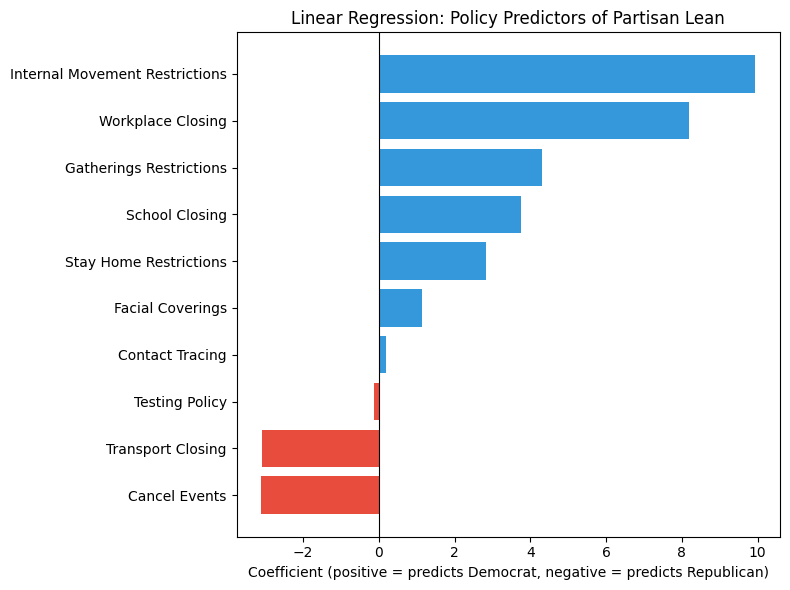

In [31]:

# Coefficients
coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_
}).sort_values('coefficient')

print("\nCoefficients:")
print(coef_df)
# Positive coefficient = higher policy intensity → more Democratic
# Negative coefficient = higher policy intensity → more Republican

# Plot coefficients
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#3498db' if c > 0 else '#e74c3c' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'].str.replace('_', ' ').str.title(),
        coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = predicts Democrat, negative = predicts Republican)')
ax.set_title('Linear Regression: Policy Predictors of Partisan Lean')
plt.tight_layout()
plt.show()


Test set predictions:
         State  Actual  Predicted
      Maryland    25.9      19.40
    New Mexico     7.0       5.49
      Virginia     4.6     -11.16
     Wisconsin    -4.1     -19.07
North Carolina    -4.8      19.46
South Carolina   -18.6     -18.91
       Indiana   -20.0       6.52
       Montana   -20.0     -14.03
     Louisiana   -20.5      -8.70
      Nebraska   -24.8     -36.88


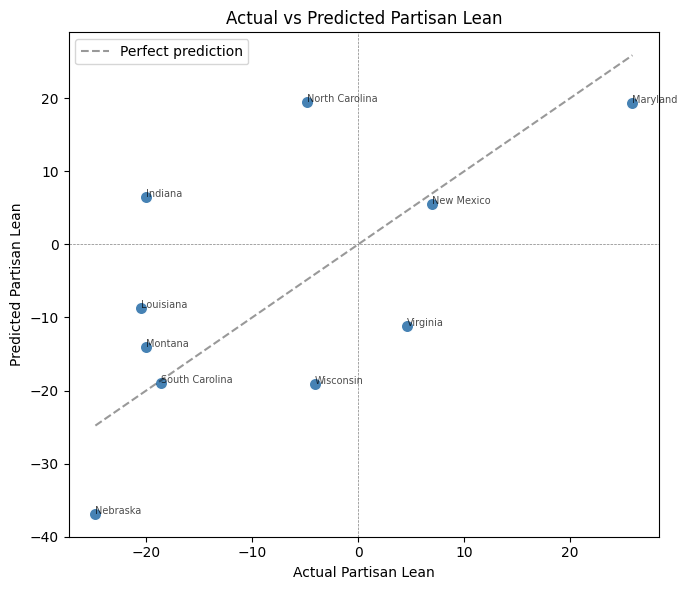

In [32]:
# Actual vs predicted plot
test_states = analysis_dta.loc[X_test.index, 'State'].values
results_df = pd.DataFrame({
    'State':     test_states,
    'Actual':    y_test.values,
    'Predicted': y_pred.round(2)
}).sort_values('Actual', ascending=False)

print("\nTest set predictions:")
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, color='steelblue', edgecolor='white', s=80)
for i, row in results_df.iterrows():
    ax.annotate(row['State'], (row['Actual'], row['Predicted']),
                fontsize=7, alpha=0.7)
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()], 'k--', alpha=0.4, label='Perfect prediction')
ax.set_xlabel('Actual Partisan Lean')
ax.set_ylabel('Predicted Partisan Lean')
ax.set_title('Actual vs Predicted Partisan Lean')
ax.legend()
plt.tight_layout()
plt.show()

In [45]:

# =============================================================================
# STEP 1: PREP
# =============================================================================

feature_cols = [
    'school_closing', 'workplace_closing', 'cancel_events',
    'gatherings_restrictions', 'transport_closing', 'stay_home_restrictions',
    'internal_movement_restrictions', 'testing_policy', 'contact_tracing',
    'facial_coverings'
]
# Note: dropping 'State' from features — it's an identifier not a predictor

X = leaning[feature_cols]
y = leaning['Party of Partisan Lean']  # 'Republican' / 'Democratic'

# =============================================================================
# STEP 2: TRAIN/TEST SPLIT
# =============================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y   # ensures both splits have balanced R/D representation
)

print(f"Training set: {len(X_train)} states")
print(f"Test set:     {len(X_test)} states")
print(f"\nTraining Party distribution:\n{y_train.value_counts()}")
print(f"\nTest Party distribution:\n{y_test.value_counts()}")

# =============================================================================
# STEP 3: SCALE AND FIT
# =============================================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on training data
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

model = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
# C=0.1 = regularization, important with small N
model.fit(X_train_scaled, y_train)

Training set: 35 states
Test set:     15 states

Training Party distribution:
Party of Partisan Lean
Republican    22
Democrat      13
Name: count, dtype: int64

Test Party distribution:
Party of Partisan Lean
Republican    9
Democrat      6
Name: count, dtype: int64


,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
# =============================================================================
# STEP 4: EVALUATE
# =============================================================================

y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_pred_prob):.3f}")



--- Classification Report ---
              precision    recall  f1-score   support

    Democrat       0.80      0.67      0.73         6
  Republican       0.80      0.89      0.84         9

    accuracy                           0.80        15
   macro avg       0.80      0.78      0.78        15
weighted avg       0.80      0.80      0.80        15

AUC: 0.796


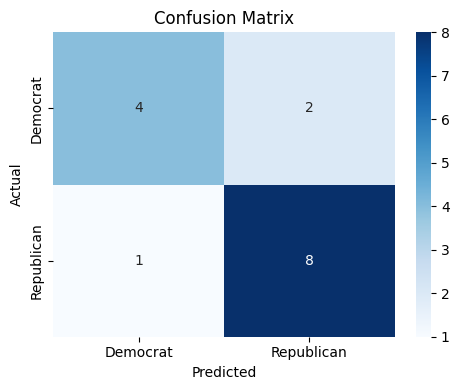

In [47]:
# =============================================================================
# STEP 5: CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

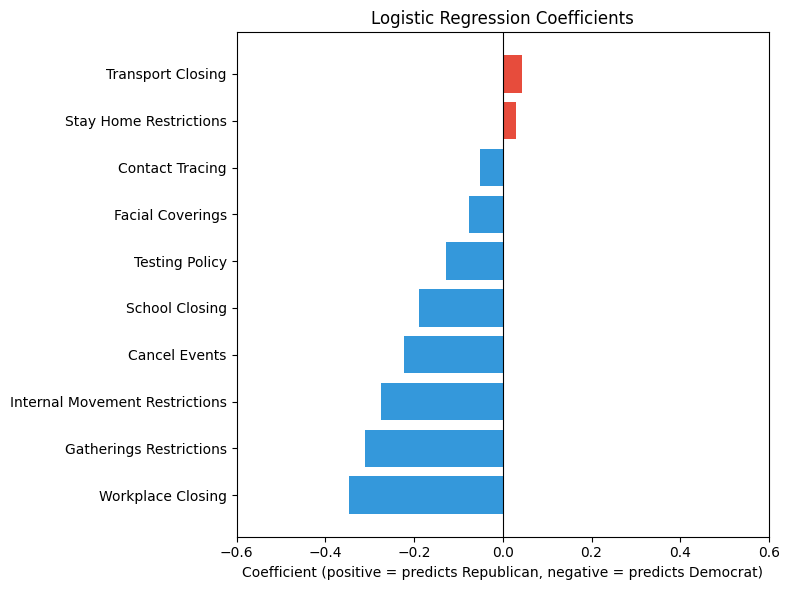


Coefficients (sorted by abs value):
                          feature  coefficient
1               workplace_closing    -0.346023
3         gatherings_restrictions    -0.309668
6  internal_movement_restrictions    -0.275651
2                   cancel_events    -0.221563
0                  school_closing    -0.188003
7                  testing_policy    -0.127914
9                facial_coverings    -0.076813
8                 contact_tracing    -0.050700
4               transport_closing     0.043957
5          stay_home_restrictions     0.030512


In [48]:
# =============================================================================
# STEP 6: COEFFICIENTS — which policies matter most
# =============================================================================

coef_df = pd.DataFrame({
    'feature':     feature_cols,
    'coefficient': model.coef_[0]
}).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'].str.replace('_', ' ').str.title(),
        coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlim(-0.6, 0.6)
ax.set_xlabel(f'Coefficient (positive = predicts {model.classes_[1]}, negative = predicts {model.classes_[0]})')
ax.set_title('Logistic Regression Coefficients')
plt.tight_layout()
plt.show()

print("\nCoefficients (sorted by abs value):")
print(coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index))


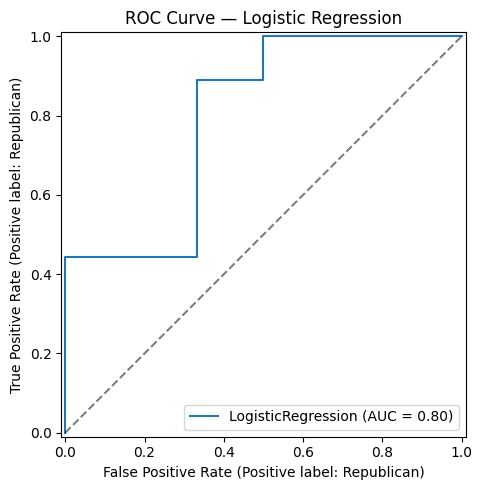

In [49]:

# =============================================================================
# STEP 7: ROC CURVE
# =============================================================================

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_title('ROC Curve — Logistic Regression')
plt.tight_layout()
plt.show()

In [50]:


# =============================================================================
# STEP 8: SEE WHICH STATES WERE MISCLASSIFIED
# =============================================================================

test_states = analysis_dta.loc[X_test.index, 'State'].values

results_df = pd.DataFrame({
    'State':          test_states,
    'Actual':         y_test.values,
    'Predicted':      y_pred,
    'Prob_class1':    y_pred_prob.round(3),
    'Correct':        y_test.values == y_pred
}).sort_values('Prob_class1', ascending=False)

print("\nTest set predictions:")
print(results_df.to_string(index=False))
print(f"\nMisclassified states:")
print(results_df[~results_df['Correct']][['State', 'Actual', 'Predicted', 'Prob_class1']])


Test set predictions:
        State     Actual  Predicted  Prob_class1  Correct
     Nebraska Republican Republican        0.924     True
      Alabama Republican Republican        0.910     True
         Utah Republican Republican        0.909     True
     Oklahoma Republican Republican        0.906     True
New Hampshire   Democrat Republican        0.847    False
        Maine   Democrat Republican        0.787    False
         Ohio Republican Republican        0.722     True
    Louisiana Republican Republican        0.654     True
        Texas Republican Republican        0.567     True
    Tennessee Republican Republican        0.540     True
       Oregon   Democrat   Democrat        0.484     True
       Alaska Republican   Democrat        0.329    False
     Maryland   Democrat   Democrat        0.323     True
   New Mexico   Democrat   Democrat        0.304     True
       Hawaii   Democrat   Democrat        0.289     True

Misclassified states:
            State      Act